# **Notebook entregable**

Incluye:

- Exploración y limpieza de datos.
- Tratamiento de variables financieras y textual
- Ingeniería de características
- Clasificación de gastos
- Análisis financiero
- Entrenamiento y evaluación de modelos
- Métricas de desempeño
- Serialización de modelos (.pkl o .joblib)

## **Exploración de datos**

### **Carga de librerías y dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("dataset_finance_ai_110_usuarios.csv")

df.head()

,usuario_id,nombre,perfil_usuario,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
0,1,Paula Flores,Usuario que usa principalmente crédito,2026-07-01,2026-07-31,2026-07-01,reparación del coche,40.11,Consumo,Transporte,Esencial,tarjeta de crédito,67.4
1,1,Paula Flores,Usuario que usa principalmente crédito,2026-07-01,2026-07-31,2026-07-01,súper,121.08,Consumo,Alimentación,Esencial,transferencia bancaria,NaN
2,1,Paula Flores,Usuario que usa principalmente crédito,2026-07-01,2026-07-31,2026-07-01,reparación inesperada,196.97,Consumo,Otros,NaN,tarjeta de crédito,63.0
3,1,Paula Flores,Usuario que usa principalmente crédito,2026-07-01,2026-07-31,2026-07-01,colegiatura,189.72,Consumo,Educación,Esencial,tarjeta de crédito,47.2
4,1,Paula Flores,Usuario que usa principalmente crédito,2026-07-01,2026-07-31,2026-07-04,pasaje,356.55,Consumo,Transporte,Esencial,tarjeta de crédito,40.0


In [2]:
df.tail()

,usuario_id,nombre,perfil_usuario,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
4317,110,Mauricio Bravo,Emprendedor,2026-07-01,2026-07-31,2026-07-26,gasolina,1910.15,Consumo,Transporte,Esencial,tarjeta de débito,NaN
4318,110,Mauricio Bravo,Emprendedor,2026-07-01,2026-07-31,2026-07-26,apoyo familiar,379.56,Consumo,Otros,NaN,tarjeta de crédito,66.2
4319,110,Mauricio Bravo,Emprendedor,2026-07-01,2026-07-31,2026-07-26,cobro a cliente,7422.94,Ingreso,NaN,NaN,transferencia bancaria,NaN
4320,110,Mauricio Bravo,Emprendedor,2026-07-01,2026-07-31,2026-07-27,despensa de la semana,804.13,Consumo,Alimentación,Esencial,transferencia bancaria,NaN
4321,110,Mauricio Bravo,Emprendedor,2026-07-01,2026-07-31,2026-07-28,boliche,1663.76,Consumo,Entretenimiento y ocio,Discrecional,tarjeta de débito,NaN


In [3]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 4322
Columnas: 13


### **Exploración de las columnas**

In [4]:
df.columns

Index(['usuario_id', 'nombre', 'perfil_usuario', 'periodo_inicio',
       'periodo_fin', 'fecha', 'descripcion', 'monto', 'tipo_movimiento',
       'categoria', 'grupo', 'tipo_pago', 'tasa_interes_tarjeta'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4322 entries, 0 to 4321
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usuario_id            4322 non-null   int64  
 1   nombre                4322 non-null   str    
 2   perfil_usuario        4322 non-null   str    
 3   periodo_inicio        4322 non-null   str    
 4   periodo_fin           4322 non-null   str    
 5   fecha                 4322 non-null   str    
 6   descripcion           4322 non-null   str    
 7   monto                 4322 non-null   float64
 8   tipo_movimiento       4322 non-null   str    
 9   categoria             3660 non-null   str    
 10  grupo                 3509 non-null   str    
 11  tipo_pago             4322 non-null   str    
 12  tasa_interes_tarjeta  1116 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 439.1 KB


In [6]:
df = df.drop(columns=["perfil_usuario"])

In [7]:
df.columns

Index(['usuario_id', 'nombre', 'periodo_inicio', 'periodo_fin', 'fecha',
       'descripcion', 'monto', 'tipo_movimiento', 'categoria', 'grupo',
       'tipo_pago', 'tasa_interes_tarjeta'],
      dtype='str')

In [8]:
df.shape[1]

12

### **Estadística descriptiva**

In [9]:
df.describe()

,usuario_id,monto,tasa_interes_tarjeta
count,4322.000000,4322.000000,1116.000000
mean,55.571032,1166.217529,57.579301
std,31.903815,3279.051540,13.040609
min,1.000000,30.840000,35.500000
25%,28.000000,159.830000,47.200000
50%,56.000000,358.375000,57.350000
75%,83.000000,807.320000,66.125000
max,110.000000,48087.070000,95.300000


La media del monto es superior a la mediana, lo que sugiere una distribución sesgada hacia valores altos y la presencia de movimientos financieros de gran magnitud.

In [10]:
df.isnull().sum()

usuario_id                 0
nombre                     0
periodo_inicio             0
periodo_fin                0
fecha                      0
descripcion                0
monto                      0
tipo_movimiento            0
categoria                662
grupo                    813
tipo_pago                  0
tasa_interes_tarjeta    3206
dtype: int64

In [11]:
nulos = pd.DataFrame({
    "cantidad": df.isnull().sum(),
    "porcentaje": df.isnull().mean() * 100
})

nulos

,cantidad,porcentaje
usuario_id,0,0.000000
nombre,0,0.000000
periodo_inicio,0,0.000000
periodo_fin,0,0.000000
fecha,0,0.000000
descripcion,0,0.000000
monto,0,0.000000
tipo_movimiento,0,0.000000
categoria,662,15.316983
grupo,813,18.810736


### **Exploración de datos nulos**

In [12]:
df[df["categoria"].isnull()].head()

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
10,1,Paula Flores,2026-07-01,2026-07-31,2026-07-09,pagaré bancario,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
22,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,nómina,3599.74,Ingreso,NaN,NaN,transferencia bancaria,NaN
23,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,pago TDC,559.58,Pago de deuda,NaN,NaN,transferencia bancaria,NaN
30,1,Paula Flores,2026-07-01,2026-07-31,2026-07-22,CETES Directo,104.45,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
38,1,Paula Flores,2026-07-01,2026-07-31,2026-07-27,bonos gubernamentales,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN


In [13]:
df[df["grupo"].isnull()].head()

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
2,1,Paula Flores,2026-07-01,2026-07-31,2026-07-01,reparación inesperada,196.97,Consumo,Otros,NaN,tarjeta de crédito,63.0
10,1,Paula Flores,2026-07-01,2026-07-31,2026-07-09,pagaré bancario,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
22,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,nómina,3599.74,Ingreso,NaN,NaN,transferencia bancaria,NaN
23,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,pago TDC,559.58,Pago de deuda,NaN,NaN,transferencia bancaria,NaN
26,1,Paula Flores,2026-07-01,2026-07-31,2026-07-17,apoyo familiar,54.57,Consumo,Otros,NaN,tarjeta de crédito,61.0


In [14]:
#verifica que tasa_interes_tarjeta salga sólo en tipo_pago = tarjeta_credito
df[df["tasa_interes_tarjeta"].isnull()].head()

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
1,1,Paula Flores,2026-07-01,2026-07-31,2026-07-01,súper,121.08,Consumo,Alimentación,Esencial,transferencia bancaria,NaN
7,1,Paula Flores,2026-07-01,2026-07-31,2026-07-08,peaje,55.70,Consumo,Transporte,Esencial,transferencia bancaria,NaN
8,1,Paula Flores,2026-07-01,2026-07-31,2026-07-08,súper,108.21,Consumo,Alimentación,Esencial,efectivo,NaN
10,1,Paula Flores,2026-07-01,2026-07-31,2026-07-09,pagaré bancario,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
11,1,Paula Flores,2026-07-01,2026-07-31,2026-07-09,peaje,148.09,Consumo,Transporte,Esencial,efectivo,NaN


In [15]:
#identifica valores nulos en categoría
pd.crosstab(
    df["tipo_movimiento"],
    df["categoria"].isnull(),
    margins=True
)

categoria,False,True,All
tipo_movimiento,,,
Ahorro e inversión,0,204,204
Consumo,3660,0,3660
Ingreso,0,254,254
Pago de deuda,0,204,204
All,3660,662,4322


#### **Nan en Categoría**

In [16]:
tipos_especiales = [
    "Ingreso",
    "Pago de deuda",
    "Ahorro e inversión"
]

df_especiales = df[
    df["tipo_movimiento"].isin(tipos_especiales)
]

df_especiales.head()

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
10,1,Paula Flores,2026-07-01,2026-07-31,2026-07-09,pagaré bancario,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
22,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,nómina,3599.74,Ingreso,NaN,NaN,transferencia bancaria,NaN
23,1,Paula Flores,2026-07-01,2026-07-31,2026-07-15,pago TDC,559.58,Pago de deuda,NaN,NaN,transferencia bancaria,NaN
30,1,Paula Flores,2026-07-01,2026-07-31,2026-07-22,CETES Directo,104.45,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN
38,1,Paula Flores,2026-07-01,2026-07-31,2026-07-27,bonos gubernamentales,100.00,Ahorro e inversión,NaN,NaN,transferencia bancaria,NaN


Los movimientos Ingreso, Ahorro e inversión y Pago de Deuda no necesitan clasificarse en una categoría, por lo tanto, no hay que eliminar esos NaN ni son errores en la base de datos.

#### **NaN en grupo**

In [17]:
df.groupby("tipo_movimiento")["grupo"].apply(
    lambda x: x.isna().sum()
)

tipo_movimiento
Ahorro e inversión    204
Consumo               151
Ingreso               254
Pago de deuda         204
Name: grupo, dtype: int64

#### **NaN en consumo**

In [18]:
consumo_sin_grupo = df[
    (df["tipo_movimiento"] == "Consumo") &
    (df["grupo"].isna())
].copy()

print(consumo_sin_grupo.shape)
consumo_sin_grupo.head()

(151, 12)


,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
2,1,Paula Flores,2026-07-01,2026-07-31,2026-07-01,reparación inesperada,196.97,Consumo,Otros,NaN,tarjeta de crédito,63.0
26,1,Paula Flores,2026-07-01,2026-07-31,2026-07-17,apoyo familiar,54.57,Consumo,Otros,NaN,tarjeta de crédito,61.0
95,3,Arturo Ortega,2026-07-01,2026-07-31,2026-07-06,cargo bancario,134.61,Consumo,Otros,NaN,efectivo,NaN
103,3,Arturo Ortega,2026-07-01,2026-07-31,2026-07-11,seguro personal,161.65,Consumo,Otros,NaN,tarjeta de crédito,37.8
108,3,Arturo Ortega,2026-07-01,2026-07-31,2026-07-16,cargo bancario,87.96,Consumo,Otros,NaN,tarjeta de crédito,42.6


In [19]:
consumo_sin_grupo["categoria"].isna().sum()

np.int64(0)

In [20]:
consumo_sin_grupo["categoria"].value_counts(dropna=False)

categoria
Otros    151
Name: count, dtype: int64

In [21]:
consumo_sin_grupo[
    ["descripcion", "categoria", "grupo"]
].value_counts(dropna=False)

descripcion            categoria  grupo
regalo para alguien    Otros      NaN      12
pago de impuestos      Otros      NaN      12
apoyo familiar         Otros      NaN      11
cargo bancario         Otros      NaN      11
donación               Otros      NaN      10
gasto imprevisto       Otros      NaN       9
abogado                Otros      NaN       9
comisión bancaria      Otros      NaN       8
mascota                Otros      NaN       8
documentos             Otros      NaN       8
multa                  Otros      NaN       8
alimento para mascota  Otros      NaN       7
pago al SAT            Otros      NaN       7
trámite                Otros      NaN       7
cuota anual            Otros      NaN       6
veterinario            Otros      NaN       6
reparación inesperada  Otros      NaN       4
seguro personal        Otros      NaN       4
contador               Otros      NaN       4
Name: count, dtype: int64

In [22]:
df.groupby("categoria")["grupo"].agg(
    total="size",
    con_grupo="count",
    sin_grupo=lambda x: x.isna().sum()
).sort_values("sin_grupo", ascending=False)

,total,con_grupo,sin_grupo
categoria,,,
Otros,151,0,151
Alimentación,1371,1371,0
Compras personales,392,392,0
Educación,139,139,0
Entretenimiento y ocio,182,182,0
Salud,121,121,0
Suscripciones digitales,84,84,0
Transporte,658,658,0
Viajes y vacaciones,95,95,0


##### **Observaciones: Valores faltantes**

Se identificaron 662 valores nulos en la variable categoría. AL analizar la relación con tipo_movimiento, se observó que corresponden a movimientos tipo Ingreso (254), Pago de deuda (204) y Ahorro e inversión (204). Debido a que la variable categoría clasifica movimientos de consimo, los valores faltantes se consideran estructurales en lugar de datos perdidos. Por este motivo, no se imputaron ni eliminaron en la limpieza del dataset.

Mismo comportamiento se observó en la variable grupo y tasa_interes_tarjeta.

En tasa_interes_tarjeta estos valores nulos son esperados cuando la transacción no se realizó con tarjeta de crédito. Así mismo, en consumo se reportaron 151 NaN, los cuales representan la categoría otro, en la cual se añaden todas las transacciones que no pueden ser clasificadas. Por tal motivo, tampoco deben eliminarse o rellenarse dichos valores nulos.

### **Exploración tasa de interés**

In [23]:
#Corrobora que no haya trasnferencias con tasa de interés cuando se utiliza un método de pago diferente a trajeta de crédito
df.groupby("tipo_pago")["tasa_interes_tarjeta"].agg(
    cantidad="count",
    promedio="mean",
    minimo="min",
    maximo="max"
)

,cantidad,promedio,minimo,maximo
tipo_pago,,,,
efectivo,0,NaN,NaN,NaN
tarjeta de crédito,1116,57.579301,35.5,95.3
tarjeta de débito,0,NaN,NaN,NaN
transferencia bancaria,0,NaN,NaN,NaN


### **Duplicados y valores únicos**

In [24]:
df.duplicated().sum()

np.int64(0)

In [26]:
columnas_categoricas = [
    "tipo_movimiento",
    "categoria",
    "grupo",
    "tipo_pago"
]

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False))


--- tipo_movimiento ---
tipo_movimiento
Consumo               3660
Ingreso                254
Ahorro e inversión     204
Pago de deuda          204
Name: count, dtype: int64

--- categoria ---
categoria
Alimentación               1371
NaN                         662
Transporte                  658
Vivienda                    467
Compras personales          392
Entretenimiento y ocio      182
Otros                       151
Educación                   139
Salud                       121
Viajes y vacaciones          95
Suscripciones digitales      84
Name: count, dtype: int64

--- grupo ---
grupo
Esencial        2756
NaN              813
Discrecional     753
Name: count, dtype: int64

--- tipo_pago ---
tipo_pago
transferencia bancaria    1452
tarjeta de débito         1135
tarjeta de crédito        1116
efectivo                   619
Name: count, dtype: int64


### **Exploración por categoría**

In [27]:
df["categoria"].value_counts()

categoria
Alimentación               1371
Transporte                  658
Vivienda                    467
Compras personales          392
Entretenimiento y ocio      182
Otros                       151
Educación                   139
Salud                       121
Viajes y vacaciones          95
Suscripciones digitales      84
Name: count, dtype: int64

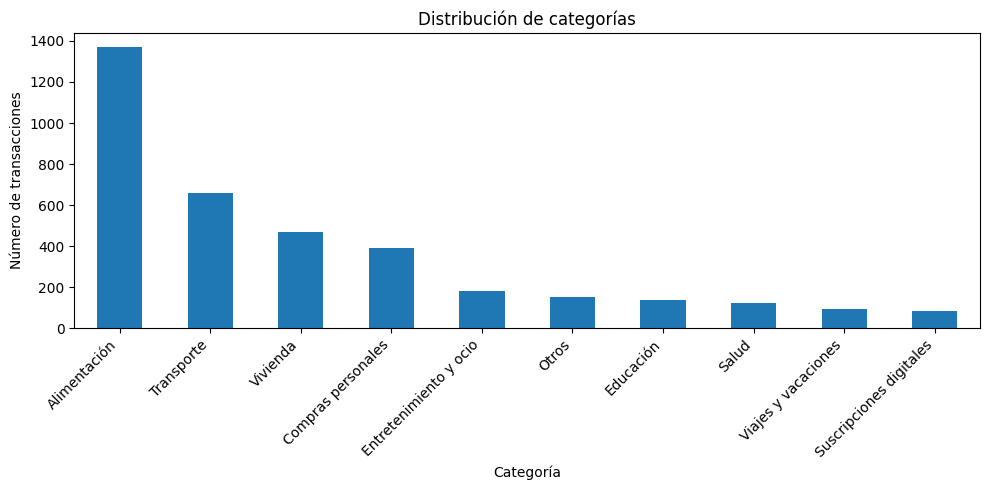

In [28]:
df["categoria"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribución de categorías")
plt.xlabel("Categoría")
plt.ylabel("Número de transacciones")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#muestra categorías con desbalance*

## **Limpieza de datos**

### **Corrección formato de las fechas**

In [29]:
columnas_fecha = [
    "periodo_inicio",
    "periodo_fin",
    "fecha"
]

for columna in columnas_fecha:
    df[columna] = pd.to_datetime(
        df[columna],
        errors="coerce"
    )

In [30]:
df.dtypes

usuario_id                       int64
nombre                             str
periodo_inicio          datetime64[us]
periodo_fin             datetime64[us]
fecha                   datetime64[us]
descripcion                        str
monto                          float64
tipo_movimiento                    str
categoria                          str
grupo                              str
tipo_pago                          str
tasa_interes_tarjeta           float64
dtype: object

In [31]:
#comprueba que no haya nulos después de la correción
df[columnas_fecha].isnull().sum()

periodo_inicio    0
periodo_fin       0
fecha             0
dtype: int64

### **Validación de montos**

In [32]:
df["monto"].describe()

count     4322.000000
mean      1166.217529
std       3279.051540
min         30.840000
25%        159.830000
50%        358.375000
75%        807.320000
max      48087.070000
Name: monto, dtype: float64

In [33]:
df[df["monto"] <= 0]

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta


No hay montos iguales o menores a cero.

### **Manejo de outliers**

In [34]:
Q1 = df["monto"].quantile(0.25)
Q3 = df["monto"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: -811.405
Límite superior: 1778.5549999999998


In [35]:
posibles_outliers = df[
    (df["monto"] < limite_inferior) |
    (df["monto"] > limite_superior)
]

posibles_outliers.sort_values(
    "monto",
    ascending=False
).head(20)

,usuario_id,nombre,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_interes_tarjeta
2666,69,Bruno Aguilar,2026-07-01,2026-07-31,2026-07-01,jubilación,48087.07,Ingreso,NaN,NaN,transferencia bancaria,NaN
777,20,Francisco Rojas,2026-07-01,2026-07-31,2026-07-15,nómina,39425.00,Ingreso,NaN,NaN,transferencia bancaria,NaN
794,20,Francisco Rojas,2026-07-01,2026-07-31,2026-07-30,pago de trabajo,39425.00,Ingreso,NaN,NaN,transferencia bancaria,NaN
3521,90,Bruno Bravo,2026-07-01,2026-07-31,2026-07-24,ventas del negocio,38972.07,Ingreso,NaN,NaN,transferencia bancaria,NaN
1942,50,Sofía Rojas,2026-07-01,2026-07-31,2026-07-15,pago de trabajo,35572.18,Ingreso,NaN,NaN,transferencia bancaria,NaN
1965,50,Sofía Rojas,2026-07-01,2026-07-31,2026-07-30,salario,35572.18,Ingreso,NaN,NaN,transferencia bancaria,NaN
4300,110,Mauricio Bravo,2026-07-01,2026-07-31,2026-07-13,cobro a cliente,35234.44,Ingreso,NaN,NaN,transferencia bancaria,NaN
372,10,Rosa Cortés,2026-07-01,2026-07-31,2026-07-15,sueldo,32676.85,Ingreso,NaN,NaN,transferencia bancaria,NaN
395,10,Rosa Cortés,2026-07-01,2026-07-31,2026-07-30,quincena,32676.85,Ingreso,NaN,NaN,transferencia bancaria,NaN
3908,100,Irene Mejía,2026-07-01,2026-07-31,2026-07-15,sueldo,32398.62,Ingreso,NaN,NaN,transferencia bancaria,NaN


Movimientos de  30,000o 40,000 pueden ser válidos en el contexto real.

In [36]:
df.groupby("tipo_movimiento")["monto"].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_movimiento,,,,,,,,
Ahorro e inversión,204.0,976.965980,1546.109106,100.00,180.4225,386.765,1038.0050,10803.59
Consumo,3660.0,508.455907,577.901082,30.84,145.0075,312.490,641.5625,4952.31
Ingreso,254.0,10708.051260,8630.887820,588.74,4813.1225,8314.020,13572.4250,48087.07
Pago de deuda,204.0,1275.967941,2418.399859,100.00,316.6950,596.030,1242.0850,20958.44


### **Revisión de textos**

In [37]:
df["descripcion"].nunique()

265

In [38]:
#normaliza los textos
df["descripcion_limpia"] = (
    df["descripcion"]
    .str.lower()
    .str.strip()
)

## **Dataset procesado**

In [39]:
df.to_csv(
    "dataset_finance_ai_limpio.csv",
    index=False
)

## **Elaboración del Clasificador**

In [40]:
df_clasificacion = df[
    df["tipo_movimiento"] == "Consumo"
].copy()

In [177]:
# ============================================
# Categorías oficiales de consumo del sistema
# ============================================

CATEGORIAS_CONSUMO = [
    "Vivienda",
    "Alimentación",
    "Transporte",
    "Salud",
    "Educación",
    "Entretenimiento y ocio",
    "Suscripciones digitales",
    "Compras personales",
    "Viajes y vacaciones",
    "Otros"
]

In [200]:
PESOS_DIMENSIONES = {

    "balance_financiero": {

        "tasa_de_gasto": 0.50,

        "margen_financiero": 0.50

    },

    "capacidad_de_ahorro": {

        "tasa_de_ahorro": 0.60,

        "aprovechamiento_del_margen_financiero": 0.40

    },

    "endeudamiento": {

        "ratio_de_endeudamiento": 0.40,

        "presion_de_la_deuda": 0.40,

        "costo_promedio_del_endeudamiento": 0.20

    },

    "comportamiento_de_consumo": {

        "indice_de_concentracion_del_gasto": 0.40,

        "predominio_del_gasto": 0.35,

        "diversificacion_del_consumo": 0.25

    }

}

In [208]:
PESOS_PERFIL_FINANCIERO = {

    "balance_financiero": 0.30,

    "capacidad_de_ahorro": 0.25,

    "endeudamiento": 0.25,

    "comportamiento_de_consumo": 0.20

}

In [190]:
def obtener_estado(puntuacion):

    if puntuacion >= 80:
        return "Saludable"

    elif puntuacion >= 50:
        return "En observación"

    else:
        return "En riesgo"

# Implementación de motor financiero

## 1.- Recepción de archivo JSON de prueba ya clasificado manualmente 

In [153]:
import json
import random
from pathlib import Path

def cargar_datos_clasificados(carpeta="datos"):
    """
    Selecciona aleatoriamente uno de los archivos JSON clasificados,
    lo convierte a un diccionario y lo devuelve.
    """

    carpeta_json = Path("perfiles_financieros_pruebas_clasificados_para_motor_financiero")

    numero = random.randint(1, 15)

    nombre_archivo = f"{numero:02d}_clasificado_manualmente.json"

    ruta_archivo = carpeta_json / nombre_archivo

    with open(ruta_archivo, "r", encoding="utf-8") as archivo:
        datos = json.load(archivo)

    print(f"Archivo seleccionado: {nombre_archivo}")

    return datos


datos_clasificados = cargar_datos_clasificados()
print (datos_clasificados)

Archivo seleccionado: 14_clasificado_manualmente.json
{'usuario': {'nombre': 'Nicolás Bravo'}, 'periodo': {'inicio': '2026-07-01', 'fin': '2026-07-31'}, 'ingresos': [{'fecha': '2026-07-01', 'descripcion': 'Diseño de sitio web', 'monto': 14000}, {'fecha': '2026-07-02', 'descripcion': 'Proyecto de identidad visual', 'monto': 9500}, {'fecha': '2026-07-03', 'descripcion': 'Consultoría de marketing', 'monto': 7000}, {'fecha': '2026-07-04', 'descripcion': 'Venta de plantillas digitales', 'monto': 3200}], 'transacciones': [{'fecha': '2026-07-02', 'descripcion': 'Renta departamento', 'monto': 7500, 'forma_pago': 'Transferencia bancaria', 'clasificacion': ['Consumo'], 'categoria': 'Vivienda', 'grupo': 'Esencial'}, {'fecha': '2026-07-04', 'descripcion': 'Internet Totalplay', 'monto': 699, 'forma_pago': 'Tarjeta de crédito', 'tasa_de_interes_de_la_tarjeta': 58, 'clasificacion': ['Consumo', 'Pago de deuda'], 'categoria': 'Otros', 'grupo': 'Esencial'}, {'fecha': '2026-07-05', 'descripcion': 'Adobe 

## 2.- Generación de varibles globales

In [167]:
def calcular_ingreso_mensual(datos_clasificados):
    """
    Calcula el ingreso mensual del usuario.

    Parámetros:
        datos_clasificados (dict): Diccionario con la información del usuario.

    Retorna:
        float: Suma de todos los ingresos registrados durante el periodo.
    """

    ingreso_mensual = 0.0

    for ingreso in datos_clasificados["ingresos"]:
        ingreso_mensual += ingreso["monto"]

    return ingreso_mensual

ingreso_mensual = calcular_ingreso_mensual(datos_clasificados)

print(f"Ingreso mensual: ${ingreso_mensual:,.2f}")

Ingreso mensual: $33,700.00


In [168]:
def calcular_consumo_total_mensual(datos_clasificados):
    """
    Calcula el consumo total mensual del usuario.

    Se consideran únicamente las transacciones cuya clasificación
    contenga exclusivamente la etiqueta "Consumo".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Consumo total mensual.
    """

    consumo_total_mensual = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if (
            "Consumo" in clasificacion
            and len(clasificacion) == 1
        ):
            consumo_total_mensual += transaccion["monto"]

    return consumo_total_mensual

consumo_total_mensual = calcular_consumo_total_mensual(datos_clasificados)

print(f"Consumo total mensual: ${consumo_total_mensual:,.2f}")

Consumo total mensual: $12,800.00


In [170]:
def calcular_pago_mensual_de_deudas(datos_clasificados):
    """
    Calcula el pago mensual de deudas del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Pago de deuda", independientemente
    de si también pertenecen a otra clasificación.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Pago mensual de deudas.
    """

    pago_mensual_de_deudas = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Pago de deuda" in clasificacion:
            pago_mensual_de_deudas += transaccion["monto"]

    return pago_mensual_de_deudas

pago_mensual_de_deudas = calcular_pago_mensual_de_deudas(datos_clasificados)

print(f"Pago mensual de deudas: ${pago_mensual_de_deudas:,.2f}")

Pago mensual de deudas: $9,914.00


In [171]:
def calcular_ahorro_e_inversion_total(datos_clasificados):
    """
    Calcula el ahorro e inversión total del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Ahorro e inversión".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Ahorro e inversión total.
    """

    ahorro_e_inversion_total = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Ahorro e inversión" in clasificacion:
            ahorro_e_inversion_total += transaccion["monto"]

    return ahorro_e_inversion_total

ahorro_e_inversion_total = calcular_ahorro_e_inversion_total(datos_clasificados)

print(f"Ahorro e inversión total: ${ahorro_e_inversion_total:,.2f}")

Ahorro e inversión total: $6,000.00


In [172]:
def calcular_egreso_total(consumo_total_mensual, pago_mensual_de_deudas):
    """
    Calcula el egreso total del usuario.

    El egreso total corresponde a la suma del consumo total mensual
    y el pago mensual de deudas.

    Parámetros:
        consumo_total_mensual (float): Consumo total mensual del usuario.
        pago_mensual_de_deudas (float): Pago mensual de deudas del usuario.

    Retorna:
        float: Egreso total del usuario.
    """

    egreso_total = consumo_total_mensual + pago_mensual_de_deudas

    return egreso_total

egreso_total = calcular_egreso_total(
    consumo_total_mensual,
    pago_mensual_de_deudas
)

print(f"Egreso total: ${egreso_total:,.2f}")

Egreso total: $22,714.00


In [173]:
def calcular_balance_mensual(ingreso_mensual, egreso_total):
    """
    Calcula el balance mensual del usuario.

    El balance mensual corresponde a la diferencia entre el ingreso
    mensual y el egreso total del periodo.

    Parámetros:
        ingreso_mensual (float): Ingreso mensual del usuario.
        egreso_total (float): Egreso total del usuario.

    Retorna:
        float: Balance mensual del usuario.
    """

    balance_mensual = ingreso_mensual - egreso_total

    return balance_mensual

balance_mensual = calcular_balance_mensual(
    ingreso_mensual,
    egreso_total
)

print(f"Balance mensual: ${balance_mensual:,.2f}")

Balance mensual: $10,986.00


In [174]:
def calcular_consumo_total_por_categoria(datos_clasificados):
    """
    Calcula el consumo total por categoría del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Consumo", independientemente de que
    también estén clasificadas como "Pago de deuda".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Consumo total por categoría.
    """

    consumo_total_por_categoria = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Consumo" in clasificacion:
            consumo_total_por_categoria += transaccion["monto"]

    return consumo_total_por_categoria

consumo_total_por_categoria = calcular_consumo_total_por_categoria(datos_clasificados)

print(f"Consumo total por categoría: ${consumo_total_por_categoria:,.2f}")

Consumo total por categoría: $19,514.00


In [178]:
def calcular_gasto_por_categoria(datos_clasificados):
    """
    Calcula el gasto acumulado por categoría de consumo.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Consumo", independientemente de que
    también estén clasificadas como "Pago de deuda".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        dict: Diccionario con el gasto acumulado por cada categoría.
    """

    # Inicializar todas las categorías en 0.0
    gasto_por_categoria = {
        categoria: 0.0
        for categoria in CATEGORIAS_CONSUMO
    }

    # Recorrer las transacciones
    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Consumo" in clasificacion:

            categoria = transaccion["categoria"]

            gasto_por_categoria[categoria] += transaccion["monto"]

    return gasto_por_categoria

gasto_por_categoria = calcular_gasto_por_categoria(datos_clasificados)

print("Gasto por categoría:")

for categoria, monto in gasto_por_categoria.items():
    print(f"{categoria}: ${monto:,.2f}")


Gasto por categoría:
Vivienda: $7,500.00
Alimentación: $2,400.00
Transporte: $1,300.00
Salud: $1,600.00
Educación: $0.00
Entretenimiento y ocio: $780.00
Suscripciones digitales: $0.00
Compras personales: $0.00
Viajes y vacaciones: $0.00
Otros: $5,934.00


In [179]:
def calcular_distribucion_porcentual_gasto(
    gasto_por_categoria,
    consumo_total_por_categoria
):
    """
    Calcula la distribución porcentual del gasto por categoría.

    La distribución porcentual representa el porcentaje que ocupa
    cada categoría respecto al consumo total por categoría.

    Parámetros:
        gasto_por_categoria (dict): Gasto acumulado por categoría.
        consumo_total_por_categoria (float): Consumo total por categoría.

    Retorna:
        dict: Distribución porcentual del gasto por categoría.
    """

    # Inicializar todas las categorías en 0.0
    distribucion_porcentual_gasto = {
        categoria: 0.0
        for categoria in CATEGORIAS_CONSUMO
    }

    # Evitar división entre cero
    if consumo_total_por_categoria == 0.0:
        return distribucion_porcentual_gasto

    # Calcular la distribución porcentual
    for categoria in CATEGORIAS_CONSUMO:

        distribucion_porcentual_gasto[categoria] = (
            gasto_por_categoria[categoria]
            / consumo_total_por_categoria
        ) * 100

    return distribucion_porcentual_gasto

distribucion_porcentual_gasto = calcular_distribucion_porcentual_gasto(
    gasto_por_categoria,
    consumo_total_por_categoria
)

print("Distribución porcentual del gasto:")

for categoria, porcentaje in distribucion_porcentual_gasto.items():
    print(f"{categoria}: {porcentaje:.2f}%")

Distribución porcentual del gasto:
Vivienda: 38.43%
Alimentación: 12.30%
Transporte: 6.66%
Salud: 8.20%
Educación: 0.00%
Entretenimiento y ocio: 4.00%
Suscripciones digitales: 0.00%
Compras personales: 0.00%
Viajes y vacaciones: 0.00%
Otros: 30.41%


In [166]:
def calcular_tasa_interes_promedio_ponderada(datos_clasificados):
    """
    Calcula la tasa de interés promedio ponderada de las compras
    realizadas con tarjeta de crédito.

    El promedio se calcula utilizando el monto de cada transacción
    como peso.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Tasa de interés promedio ponderada.
    """

    monto_total_credito = 0.0
    suma_ponderada = 0.0

    # Recorrer las transacciones
    for transaccion in datos_clasificados["transacciones"]:

        if transaccion["forma_pago"] == "Tarjeta de crédito":

            monto = transaccion["monto"]
            tasa = transaccion["tasa_de_interes_de_la_tarjeta"]

            monto_total_credito += monto
            suma_ponderada += monto * tasa

    # Evitar división entre cero
    if monto_total_credito == 0.0:
        return 0.0

    tasa_interes_promedio_ponderada = (
        suma_ponderada / monto_total_credito
    )

    return tasa_interes_promedio_ponderada

tasa_interes_promedio_ponderada = calcular_tasa_interes_promedio_ponderada(
    datos_clasificados
)

print(
    f"Tasa de interés promedio ponderada: "
    f"{tasa_interes_promedio_ponderada:.2f}%"
)

Tasa de interés promedio ponderada: 58.00%


In [181]:
def calcular_variables_globales(datos_clasificados):
    """
    Calcula todas las variables globales necesarias para el
    motor de análisis financiero.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        dict: Diccionario con todas las variables globales.
    """

    # Variables obtenidas directamente del diccionario
    ingreso_mensual = calcular_ingreso_mensual(datos_clasificados)

    consumo_total_mensual = calcular_consumo_total_mensual(
        datos_clasificados
    )

    pago_mensual_de_deudas = calcular_pago_mensual_de_deudas(
        datos_clasificados
    )

    ahorro_e_inversion_total = calcular_ahorro_e_inversion_total(
        datos_clasificados
    )

    consumo_total_por_categoria = calcular_consumo_total_por_categoria(
        datos_clasificados
    )

    gasto_por_categoria = calcular_gasto_por_categoria(
        datos_clasificados
    )

    tasa_interes_promedio_ponderada = (
        calcular_tasa_interes_promedio_ponderada(
            datos_clasificados
        )
    )

    # Variables derivadas
    egreso_total = calcular_egreso_total(
        consumo_total_mensual,
        pago_mensual_de_deudas
    )

    balance_mensual = calcular_balance_mensual(
        ingreso_mensual,
        egreso_total
    )

    distribucion_porcentual_gasto = (
        calcular_distribucion_porcentual_gasto(
            gasto_por_categoria,
            consumo_total_por_categoria
        )
    )

    # Construcción del diccionario de salida
    variables_globales = {

        "ingreso_mensual": ingreso_mensual,

        "consumo_total_mensual": consumo_total_mensual,

        "pago_mensual_de_deudas": pago_mensual_de_deudas,

        "ahorro_e_inversion_total": ahorro_e_inversion_total,

        "egreso_total": egreso_total,

        "balance_mensual": balance_mensual,

        "consumo_total_por_categoria": consumo_total_por_categoria,

        "gasto_por_categoria": gasto_por_categoria,

        "distribucion_porcentual_gasto": (
            distribucion_porcentual_gasto
        ),

        "tasa_interes_promedio_ponderada": (
            tasa_interes_promedio_ponderada
        )
    }

    return variables_globales

variables_globales = calcular_variables_globales(
    datos_clasificados
)

for nombre, valor in variables_globales.items():
    print(f"{nombre}:")
    print(valor)
    print()

print (variables_globales)


ingreso_mensual:
33700.0

consumo_total_mensual:
12800.0

pago_mensual_de_deudas:
9914.0

ahorro_e_inversion_total:
6000.0

egreso_total:
22714.0

balance_mensual:
10986.0

consumo_total_por_categoria:
19514.0

gasto_por_categoria:
{'Vivienda': 7500.0, 'Alimentación': 2400.0, 'Transporte': 1300.0, 'Salud': 1600.0, 'Educación': 0.0, 'Entretenimiento y ocio': 780.0, 'Suscripciones digitales': 0.0, 'Compras personales': 0.0, 'Viajes y vacaciones': 0.0, 'Otros': 5934.0}

distribucion_porcentual_gasto:
{'Vivienda': 38.43394486010044, 'Alimentación': 12.298862355232142, 'Transporte': 6.661883775750743, 'Salud': 8.199241570154761, 'Educación': 0.0, 'Entretenimiento y ocio': 3.997130265450446, 'Suscripciones digitales': 0.0, 'Compras personales': 0.0, 'Viajes y vacaciones': 0.0, 'Otros': 30.408937173311468}

tasa_interes_promedio_ponderada:
58.0

{'ingreso_mensual': 33700.0, 'consumo_total_mensual': 12800.0, 'pago_mensual_de_deudas': 9914.0, 'ahorro_e_inversion_total': 6000.0, 'egreso_total': 

## Generación de indicadores financieros por  cada una de las 4 dimenciones  

In [183]:
def calcular_indicadores_balance_financiero(variables_globales):
    """
    Calcula los indicadores de la dimensión Balance Financiero.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Balance Financiero.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    egreso_total = variables_globales["egreso_total"]
    balance_mensual = variables_globales["balance_mensual"]

    # Indicador 1: Balance mensual
    indicador_balance_mensual = balance_mensual

    # Indicador 2: Tasa de gasto
    if ingreso_mensual == 0.0:
        indicador_tasa_de_gasto = 0.0
    else:
        indicador_tasa_de_gasto = (
            egreso_total / ingreso_mensual
        )

    # Indicador 3: Margen financiero
    if ingreso_mensual == 0.0:
        indicador_margen_financiero = 0.0
    else:
        indicador_margen_financiero = (
            balance_mensual / ingreso_mensual
        )

    indicadores_balance_financiero = {

        "balance_mensual": indicador_balance_mensual,

        "tasa_de_gasto": indicador_tasa_de_gasto,

        "margen_financiero": indicador_margen_financiero

    }

    return indicadores_balance_financiero

indicadores_balance_financiero = (
    calcular_indicadores_balance_financiero(
        variables_globales
    )
)

print("Indicadores de Balance Financiero:\n")

for indicador, valor in indicadores_balance_financiero.items():
    print(f"{indicador}: {valor}")

print (indicadores_balance_financiero)

Indicadores de Balance Financiero:

balance_mensual: 10986.0
tasa_de_gasto: 0.6740059347181009
margen_financiero: 0.3259940652818991
{'balance_mensual': 10986.0, 'tasa_de_gasto': 0.6740059347181009, 'margen_financiero': 0.3259940652818991}


In [184]:
def calcular_indicadores_capacidad_ahorro(variables_globales):
    """
    Calcula los indicadores de la dimensión Capacidad de Ahorro.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Capacidad de Ahorro.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    ahorro_e_inversion_total = variables_globales["ahorro_e_inversion_total"]
    balance_mensual = variables_globales["balance_mensual"]

    # Indicador 1: Tasa de ahorro
    if ingreso_mensual == 0.0:
        indicador_tasa_de_ahorro = 0.0
    else:
        indicador_tasa_de_ahorro = (
            ahorro_e_inversion_total / ingreso_mensual
        )

    # Indicador 2: Ahorro e inversión del periodo
    indicador_ahorro_e_inversion_del_periodo = (
        ahorro_e_inversion_total
    )

    # Indicador 3: Aprovechamiento del margen financiero
    if balance_mensual <= 0.0:
        indicador_aprovechamiento_del_margen_financiero = 0.0
    else:
        indicador_aprovechamiento_del_margen_financiero = (
            ahorro_e_inversion_total / balance_mensual
        )

    indicadores_capacidad_ahorro = {

        "tasa_de_ahorro": indicador_tasa_de_ahorro,

        "ahorro_e_inversion_del_periodo":
            indicador_ahorro_e_inversion_del_periodo,

        "aprovechamiento_del_margen_financiero":
            indicador_aprovechamiento_del_margen_financiero

    }

    return indicadores_capacidad_ahorro

indicadores_capacidad_ahorro = (
    calcular_indicadores_capacidad_ahorro(
        variables_globales
    )
)

print("Indicadores de Capacidad de Ahorro:\n")

for indicador, valor in indicadores_capacidad_ahorro.items():
    print(f"{indicador}: {valor}")

Indicadores de Capacidad de Ahorro:

tasa_de_ahorro: 0.17804154302670624
ahorro_e_inversion_del_periodo: 6000.0
aprovechamiento_del_margen_financiero: 0.5461496450027308


In [185]:
def calcular_indicadores_endeudamiento(variables_globales):
    """
    Calcula los indicadores de la dimensión Endeudamiento.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Endeudamiento.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    pago_mensual_de_deudas = variables_globales["pago_mensual_de_deudas"]
    egreso_total = variables_globales["egreso_total"]
    tasa_interes_promedio_ponderada = (
        variables_globales["tasa_interes_promedio_ponderada"]
    )

    # Indicador 1: Ratio de endeudamiento
    if ingreso_mensual == 0.0:
        indicador_ratio_de_endeudamiento = 0.0
    else:
        indicador_ratio_de_endeudamiento = (
            pago_mensual_de_deudas / ingreso_mensual
        )

    # Indicador 2: Monto destinado al pago de deudas
    indicador_monto_destinado_al_pago_de_deudas = (
        pago_mensual_de_deudas
    )

    # Indicador 3: Presión de la deuda
    if egreso_total == 0.0:
        indicador_presion_de_la_deuda = 0.0
    else:
        indicador_presion_de_la_deuda = (
            pago_mensual_de_deudas / egreso_total
        )

    # Indicador 4: Costo promedio del endeudamiento
    indicador_costo_promedio_del_endeudamiento = (
        tasa_interes_promedio_ponderada
    )

    indicadores_endeudamiento = {

        "ratio_de_endeudamiento":
            indicador_ratio_de_endeudamiento,

        "monto_destinado_al_pago_de_deudas":
            indicador_monto_destinado_al_pago_de_deudas,

        "presion_de_la_deuda":
            indicador_presion_de_la_deuda,

        "costo_promedio_del_endeudamiento":
            indicador_costo_promedio_del_endeudamiento

    }

    return indicadores_endeudamiento

indicadores_endeudamiento = (
    calcular_indicadores_endeudamiento(
        variables_globales
    )
)

print("Indicadores de Endeudamiento:\n")

for indicador, valor in indicadores_endeudamiento.items():
    print(f"{indicador}: {valor}")

Indicadores de Endeudamiento:

ratio_de_endeudamiento: 0.2941839762611276
monto_destinado_al_pago_de_deudas: 9914.0
presion_de_la_deuda: 0.43647089900501895
costo_promedio_del_endeudamiento: 58.0


In [186]:
def calcular_indicadores_comportamiento_consumo(
    variables_globales,
    datos_clasificados
):
    """
    Calcula los indicadores de la dimensión Comportamiento de Consumo.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.
        datos_clasificados (dict): Diccionario con las transacciones
        clasificadas.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Comportamiento de Consumo.
    """

    distribucion_porcentual_gasto = (
        variables_globales["distribucion_porcentual_gasto"]
    )

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    gasto_por_categoria = (
        variables_globales["gasto_por_categoria"]
    )

    # ==========================================================
    # Indicador 1: Distribución del gasto por categoría
    # ==========================================================

    indicador_distribucion_del_gasto_por_categoria = (
        distribucion_porcentual_gasto
    )

    # ==========================================================
    # Indicador 2: Índice de concentración del gasto
    # (HHI normalizado)
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        indicador_indice_de_concentracion_del_gasto = 0.0

    else:

        hhi = 0.0

        for porcentaje in distribucion_porcentual_gasto.values():

            proporcion = porcentaje / 100

            hhi += proporcion ** 2

        n = len(CATEGORIAS_CONSUMO)

        indicador_indice_de_concentracion_del_gasto = (
            (hhi - (1 / n))
            /
            (1 - (1 / n))
        )

    # ==========================================================
    # Perfil de consumo
    # ==========================================================

    # ----------------------------------------------------------
    # Indicador de consumo 1: Predominio del gasto
    # ----------------------------------------------------------

    gasto_esencial = 0.0
    gasto_discrecional = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        if "Consumo" in transaccion["clasificacion"]:

            if transaccion["grupo"] == "Esencial":

                gasto_esencial += transaccion["monto"]

            elif transaccion["grupo"] == "Discrecional":

                gasto_discrecional += transaccion["monto"]

    if consumo_total_por_categoria == 0.0:

        indicador_predominio_del_gasto = (
            "Balance entre gastos esenciales y discrecionales"
        )

    else:

        porcentaje_esencial = (
            gasto_esencial / consumo_total_por_categoria
        )

        porcentaje_discrecional = (
            gasto_discrecional / consumo_total_por_categoria
        )

        if porcentaje_esencial >= 0.60:

            indicador_predominio_del_gasto = (
                "Predominio en gastos esenciales"
            )

        elif porcentaje_discrecional >= 0.60:

            indicador_predominio_del_gasto = (
                "Predominio en gastos discrecionales"
            )

        else:

            indicador_predominio_del_gasto = (
                "Balance entre gastos esenciales y discrecionales"
            )

    # ----------------------------------------------------------
    # Indicador de consumo 2: Tipo de consumo
    # ----------------------------------------------------------

    indice = indicador_indice_de_concentracion_del_gasto

    if indice <= 0.33:

        indicador_tipo_de_consumo = (
            "Consumo equilibrado"
        )

    elif indice <= 0.66:

        indicador_tipo_de_consumo = (
            "Consumo moderadamente concentrado"
        )

    else:

        indicador_tipo_de_consumo = (
            "Consumo altamente concentrado"
        )

    # ----------------------------------------------------------
    # Indicador de consumo 3: Diversificación del consumo
    # ----------------------------------------------------------

    categorias_utilizadas = 0

    for monto in gasto_por_categoria.values():

        if monto > 0:

            categorias_utilizadas += 1

    if categorias_utilizadas >= 5:

        indicador_diversificacion_del_consumo = (
            "Consumo diversificado"
        )

    else:

        indicador_diversificacion_del_consumo = (
            "Consumo poco diversificado"
        )

    # ----------------------------------------------------------
    # Indicador de consumo 4: Categoría predominante
    # ----------------------------------------------------------

    if consumo_total_por_categoria == 0.0:

        indicador_categoria_predominante = "Ninguna"

    else:

        indicador_categoria_predominante = max(
            distribucion_porcentual_gasto,
            key=distribucion_porcentual_gasto.get
        )

    indicadores_comportamiento_consumo = {

        "distribucion_del_gasto_por_categoria":
            indicador_distribucion_del_gasto_por_categoria,

        "indice_de_concentracion_del_gasto":
            indicador_indice_de_concentracion_del_gasto,

        "perfil_de_consumo": {

            "predominio_del_gasto":
                indicador_predominio_del_gasto,

            "tipo_de_consumo":
                indicador_tipo_de_consumo,

            "diversificacion_del_consumo":
                indicador_diversificacion_del_consumo,

            "categoria_predominante":
                indicador_categoria_predominante
        }

    }

    return indicadores_comportamiento_consumo

indicadores_comportamiento_consumo = (
    calcular_indicadores_comportamiento_consumo(
        variables_globales,
        datos_clasificados
    )
)

from pprint import pprint

print("Indicadores de Comportamiento de Consumo:\n")

pprint(indicadores_comportamiento_consumo)

Indicadores de Comportamiento de Consumo:

{'distribucion_del_gasto_por_categoria': {'Alimentación': 12.298862355232142,
                                          'Compras personales': 0.0,
                                          'Educación': 0.0,
                                          'Entretenimiento y ocio': 3.997130265450446,
                                          'Otros': 30.408937173311468,
                                          'Salud': 8.199241570154761,
                                          'Suscripciones digitales': 0.0,
                                          'Transporte': 6.661883775750743,
                                          'Viajes y vacaciones': 0.0,
                                          'Vivienda': 38.43394486010044},
 'indice_de_concentracion_del_gasto': 0.18674654454210401,
 'perfil_de_consumo': {'categoria_predominante': 'Vivienda',
                       'diversificacion_del_consumo': 'Consumo diversificado',
                       'predom

In [187]:
def calcular_indicadores_financieros(
    variables_globales,
    datos_clasificados
):
    """
    Calcula todos los indicadores financieros del sistema.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.
        datos_clasificados (dict): Diccionario con las transacciones
        clasificadas.

    Retorna:
        dict: Diccionario con los indicadores financieros de las
        cuatro dimensiones.
    """

    indicadores_balance_financiero = (
        calcular_indicadores_balance_financiero(
            variables_globales
        )
    )

    indicadores_capacidad_ahorro = (
        calcular_indicadores_capacidad_ahorro(
            variables_globales
        )
    )

    indicadores_endeudamiento = (
        calcular_indicadores_endeudamiento(
            variables_globales
        )
    )

    indicadores_comportamiento_consumo = (
        calcular_indicadores_comportamiento_consumo(
            variables_globales,
            datos_clasificados
        )
    )

    indicadores_financieros = {

        "balance_financiero":
            indicadores_balance_financiero,

        "capacidad_de_ahorro":
            indicadores_capacidad_ahorro,

        "endeudamiento":
            indicadores_endeudamiento,

        "comportamiento_de_consumo":
            indicadores_comportamiento_consumo

    }

    return indicadores_financieros

indicadores_financieros = (
    calcular_indicadores_financieros(
        variables_globales,
        datos_clasificados
    )
)

from pprint import pprint

print("Indicadores financieros:\n")

pprint(indicadores_financieros)

Indicadores financieros:

{'balance_financiero': {'balance_mensual': 10986.0,
                        'margen_financiero': 0.3259940652818991,
                        'tasa_de_gasto': 0.6740059347181009},
 'capacidad_de_ahorro': {'ahorro_e_inversion_del_periodo': 6000.0,
                         'aprovechamiento_del_margen_financiero': 0.5461496450027308,
                         'tasa_de_ahorro': 0.17804154302670624},
 'comportamiento_de_consumo': {'distribucion_del_gasto_por_categoria': {'Alimentación': 12.298862355232142,
                                                                        'Compras personales': 0.0,
                                                                        'Educación': 0.0,
                                                                        'Entretenimiento y ocio': 3.997130265450446,
                                                                        'Otros': 30.408937173311468,
                                                              

## Obtención de la puntcuación y estado de cada dimensión

In [192]:
def evaluar_balance_financiero(indicadores_financieros):
    """
    Evalúa la dimensión Balance Financiero.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["balance_financiero"]

    tasa_de_gasto = indicadores["tasa_de_gasto"]
    margen_financiero = indicadores["margen_financiero"]

    # ==========================================================
    # Puntuación del indicador: Tasa de gasto
    # ==========================================================

    if tasa_de_gasto <= 0.50:
        puntuacion_tasa_de_gasto = 100

    elif tasa_de_gasto <= 0.60:
        puntuacion_tasa_de_gasto = 90

    elif tasa_de_gasto <= 0.70:
        puntuacion_tasa_de_gasto = 80

    elif tasa_de_gasto <= 0.80:
        puntuacion_tasa_de_gasto = 70

    elif tasa_de_gasto <= 0.90:
        puntuacion_tasa_de_gasto = 60

    elif tasa_de_gasto <= 1.00:
        puntuacion_tasa_de_gasto = 50

    else:
        puntuacion_tasa_de_gasto = 0

    # ==========================================================
    # Puntuación del indicador: Margen financiero
    # ==========================================================

    if margen_financiero >= 0.50:
        puntuacion_margen_financiero = 100

    elif margen_financiero >= 0.40:
        puntuacion_margen_financiero = 90

    elif margen_financiero >= 0.30:
        puntuacion_margen_financiero = 80

    elif margen_financiero >= 0.20:
        puntuacion_margen_financiero = 70

    elif margen_financiero >= 0.10:
        puntuacion_margen_financiero = 60

    elif margen_financiero >= 0.00:
        puntuacion_margen_financiero = 50

    else:
        puntuacion_margen_financiero = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["balance_financiero"]

    puntuacion_dimension = round(

        (puntuacion_tasa_de_gasto *
         pesos["tasa_de_gasto"])

        +

        (puntuacion_margen_financiero *
         pesos["margen_financiero"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_balance_financiero = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_balance_financiero

evaluacion_balance_financiero = (
    evaluar_balance_financiero(
        indicadores_financieros
    )
)

print(evaluacion_balance_financiero)

{'puntuacion': 80, 'estado': 'Saludable'}


In [195]:
def evaluar_capacidad_de_ahorro(indicadores_financieros):
    """
    Evalúa la dimensión Capacidad de Ahorro.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["capacidad_de_ahorro"]

    tasa_de_ahorro = indicadores["tasa_de_ahorro"]

    aprovechamiento_del_margen_financiero = (
        indicadores["aprovechamiento_del_margen_financiero"]
    )

    # ==========================================================
    # Puntuación del indicador: Tasa de ahorro
    # ==========================================================

    if tasa_de_ahorro >= 0.30:
        puntuacion_tasa_de_ahorro = 100

    elif tasa_de_ahorro >= 0.25:
        puntuacion_tasa_de_ahorro = 90

    elif tasa_de_ahorro >= 0.20:
        puntuacion_tasa_de_ahorro = 80

    elif tasa_de_ahorro >= 0.15:
        puntuacion_tasa_de_ahorro = 70

    elif tasa_de_ahorro >= 0.10:
        puntuacion_tasa_de_ahorro = 60

    elif tasa_de_ahorro >= 0.05:
        puntuacion_tasa_de_ahorro = 50

    else:
        puntuacion_tasa_de_ahorro = 0

    # ==========================================================
    # Puntuación del indicador:
    # Aprovechamiento del margen financiero
    # ==========================================================

    if aprovechamiento_del_margen_financiero >= 0.90:
        puntuacion_aprovechamiento = 100

    elif aprovechamiento_del_margen_financiero >= 0.75:
        puntuacion_aprovechamiento = 90

    elif aprovechamiento_del_margen_financiero >= 0.60:
        puntuacion_aprovechamiento = 80

    elif aprovechamiento_del_margen_financiero >= 0.45:
        puntuacion_aprovechamiento = 70

    elif aprovechamiento_del_margen_financiero >= 0.30:
        puntuacion_aprovechamiento = 60

    elif aprovechamiento_del_margen_financiero >= 0.15:
        puntuacion_aprovechamiento = 50

    else:
        puntuacion_aprovechamiento = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["capacidad_de_ahorro"]

    puntuacion_dimension = round(

        (puntuacion_tasa_de_ahorro *
         pesos["tasa_de_ahorro"])

        +

        (puntuacion_aprovechamiento *
         pesos["aprovechamiento_del_margen_financiero"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_capacidad_de_ahorro = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_capacidad_de_ahorro

evaluacion_capacidad_de_ahorro = (
    evaluar_capacidad_de_ahorro(
        indicadores_financieros
    )
)

print(evaluacion_capacidad_de_ahorro)

{'puntuacion': 70, 'estado': 'En observación'}


In [197]:
def evaluar_endeudamiento(indicadores_financieros):
    """
    Evalúa la dimensión Endeudamiento.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["endeudamiento"]

    ratio_de_endeudamiento = (
        indicadores["ratio_de_endeudamiento"]
    )

    presion_de_la_deuda = (
        indicadores["presion_de_la_deuda"]
    )

    costo_promedio_del_endeudamiento = (
        indicadores["costo_promedio_del_endeudamiento"]
    )

    # ==========================================================
    # Puntuación del indicador: Ratio de endeudamiento
    # ==========================================================

    if ratio_de_endeudamiento <= 0.10:
        puntuacion_ratio = 100

    elif ratio_de_endeudamiento <= 0.20:
        puntuacion_ratio = 90

    elif ratio_de_endeudamiento <= 0.30:
        puntuacion_ratio = 80

    elif ratio_de_endeudamiento <= 0.40:
        puntuacion_ratio = 70

    elif ratio_de_endeudamiento <= 0.50:
        puntuacion_ratio = 60

    elif ratio_de_endeudamiento <= 0.60:
        puntuacion_ratio = 50

    else:
        puntuacion_ratio = 0

    # ==========================================================
    # Puntuación del indicador: Presión de la deuda
    # ==========================================================

    if presion_de_la_deuda <= 0.10:
        puntuacion_presion = 100

    elif presion_de_la_deuda <= 0.20:
        puntuacion_presion = 90

    elif presion_de_la_deuda <= 0.30:
        puntuacion_presion = 80

    elif presion_de_la_deuda <= 0.40:
        puntuacion_presion = 70

    elif presion_de_la_deuda <= 0.50:
        puntuacion_presion = 60

    elif presion_de_la_deuda <= 0.60:
        puntuacion_presion = 50

    else:
        puntuacion_presion = 0

    # ==========================================================
    # Puntuación del indicador:
    # Costo promedio del endeudamiento
    # ==========================================================

    if costo_promedio_del_endeudamiento <= 10:
        puntuacion_costo = 100

    elif costo_promedio_del_endeudamiento <= 20:
        puntuacion_costo = 90

    elif costo_promedio_del_endeudamiento <= 35:
        puntuacion_costo = 80

    elif costo_promedio_del_endeudamiento <= 50:
        puntuacion_costo = 70

    elif costo_promedio_del_endeudamiento <= 65:
        puntuacion_costo = 60

    elif costo_promedio_del_endeudamiento <= 80:
        puntuacion_costo = 50

    else:
        puntuacion_costo = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["endeudamiento"]

    puntuacion_dimension = round(

        (puntuacion_ratio *
         pesos["ratio_de_endeudamiento"])

        +

        (puntuacion_presion *
         pesos["presion_de_la_deuda"])

        +

        (puntuacion_costo *
         pesos["costo_promedio_del_endeudamiento"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_endeudamiento = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_endeudamiento

evaluacion_endeudamiento = (
    evaluar_endeudamiento(
        indicadores_financieros
    )
)

print(evaluacion_endeudamiento)

{'puntuacion': 68, 'estado': 'En observación'}


In [201]:
def evaluar_comportamiento_de_consumo(
    indicadores_financieros,
    variables_globales
):
    """
    Evalúa la dimensión Comportamiento de Consumo.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    # ==========================================================
    # Caso especial:
    # No existen transacciones de consumo
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        return {

            "puntuacion": 0,

            "estado": obtener_estado(0)

        }

    indicadores = indicadores_financieros["comportamiento_de_consumo"]

    indice_de_concentracion_del_gasto = (
        indicadores["indice_de_concentracion_del_gasto"]
    )

    perfil_de_consumo = indicadores["perfil_de_consumo"]

    predominio_del_gasto = (
        perfil_de_consumo["predominio_del_gasto"]
    )

    diversificacion_del_consumo = (
        perfil_de_consumo["diversificacion_del_consumo"]
    )

    # ==========================================================
    # Puntuación del indicador:
    # Índice de concentración del gasto
    # ==========================================================

    if indice_de_concentracion_del_gasto <= 0.33:

        puntuacion_indice = 100

    elif indice_de_concentracion_del_gasto <= 0.66:

        puntuacion_indice = 70

    else:

        puntuacion_indice = 40

    # ==========================================================
    # Puntuación del indicador:
    # Predominio del gasto
    # ==========================================================

    if predominio_del_gasto == (
        "Predominio en gastos esenciales"
    ):

        puntuacion_predominio = 100

    elif predominio_del_gasto == (
        "Balance entre gastos esenciales y discrecionales"
    ):

        puntuacion_predominio = 80

    else:

        puntuacion_predominio = 50

    # ==========================================================
    # Puntuación del indicador:
    # Diversificación del consumo
    # ==========================================================

    if diversificacion_del_consumo == (
        "Consumo diversificado"
    ):

        puntuacion_diversificacion = 100

    else:

        puntuacion_diversificacion = 50

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["comportamiento_de_consumo"]

    puntuacion_dimension = round(

        (puntuacion_indice *
         pesos["indice_de_concentracion_del_gasto"])

        +

        (puntuacion_predominio *
         pesos["predominio_del_gasto"])

        +

        (puntuacion_diversificacion *
         pesos["diversificacion_del_consumo"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_comportamiento_de_consumo = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_comportamiento_de_consumo

evaluacion_comportamiento_de_consumo = (
    evaluar_comportamiento_de_consumo(
        indicadores_financieros,
        variables_globales
    )
)

print(evaluacion_comportamiento_de_consumo)

{'puntuacion': 100, 'estado': 'Saludable'}


In [202]:
def calcular_evaluacion_financiera(
    indicadores_financieros,
    variables_globales
):
    """
    Calcula la evaluación financiera de las cuatro dimensiones.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        dict: Diccionario con la puntuación y estado de cada dimensión.
    """

    evaluacion_balance_financiero = (
        evaluar_balance_financiero(
            indicadores_financieros
        )
    )

    evaluacion_capacidad_de_ahorro = (
        evaluar_capacidad_de_ahorro(
            indicadores_financieros
        )
    )

    evaluacion_endeudamiento = (
        evaluar_endeudamiento(
            indicadores_financieros
        )
    )

    evaluacion_comportamiento_de_consumo = (
        evaluar_comportamiento_de_consumo(
            indicadores_financieros,
            variables_globales
        )
    )

    evaluacion_financiera = {

        "balance_financiero":
            evaluacion_balance_financiero,

        "capacidad_de_ahorro":
            evaluacion_capacidad_de_ahorro,

        "endeudamiento":
            evaluacion_endeudamiento,

        "comportamiento_de_consumo":
            evaluacion_comportamiento_de_consumo

    }

    return evaluacion_financiera

evaluacion_financiera = (
    calcular_evaluacion_financiera(
        indicadores_financieros,
        variables_globales
    )
)

from pprint import pprint

print("Evaluación financiera:\n")

pprint(evaluacion_financiera)

Evaluación financiera:

{'balance_financiero': {'estado': 'Saludable', 'puntuacion': 80},
 'capacidad_de_ahorro': {'estado': 'En observación', 'puntuacion': 70},
 'comportamiento_de_consumo': {'estado': 'Saludable', 'puntuacion': 100},
 'endeudamiento': {'estado': 'En observación', 'puntuacion': 68}}


## Generación de recomendaciones de cada dimensión 

In [203]:
def generar_recomendaciones_balance_financiero(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Balance Financiero.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["balance_financiero"]

    balance_mensual = indicadores["balance_mensual"]
    tasa_de_gasto = indicadores["tasa_de_gasto"]
    margen_financiero = indicadores["margen_financiero"]

    estado = (
        evaluacion_financiera["balance_financiero"]["estado"]
    )

    # ==========================================================
    # Recomendación según el Balance mensual
    # ==========================================================

    if balance_mensual > 0:

        recomendaciones.append(
            "Mantener un balance mensual positivo para fortalecer la estabilidad financiera."
        )

    elif balance_mensual == 0:

        recomendaciones.append(
            "Buscar generar un balance mensual positivo incrementando los ingresos o reduciendo los gastos."
        )

    else:

        recomendaciones.append(
            "Recuperar un balance mensual positivo reduciendo gastos o incrementando los ingresos."
        )

    # ==========================================================
    # Recomendación según la Tasa de gasto
    # ==========================================================

    if tasa_de_gasto <= 0.50:

        recomendaciones.append(
            "Mantener el nivel actual de gasto respecto a los ingresos."
        )

    elif tasa_de_gasto <= 0.80:

        recomendaciones.append(
            "Continuar monitoreando el gasto para evitar que aumente."
        )

    elif tasa_de_gasto <= 1.00:

        recomendaciones.append(
            "Reducir gradualmente el porcentaje destinado al gasto mensual."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción inmediata de gastos o incrementar los ingresos para recuperar el equilibrio financiero."
        )

    # ==========================================================
    # Recomendación según el Margen financiero
    # ==========================================================

    if margen_financiero >= 0.30:

        recomendaciones.append(
            "Mantener el margen financiero actual y destinar parte del excedente al ahorro o inversión."
        )

    elif margen_financiero >= 0.10:

        recomendaciones.append(
            "Buscar incrementar gradualmente el margen financiero mediante una mejor planificación del presupuesto."
        )

    elif margen_financiero >= 0.00:

        recomendaciones.append(
            "Incrementar el margen financiero reduciendo gastos no esenciales o aumentando los ingresos."
        )

    else:

        recomendaciones.append(
            "Recuperar un margen financiero positivo disminuyendo gastos o incrementando los ingresos antes de asumir nuevos compromisos financieros."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener las prácticas financieras actuales para conservar el buen desempeño de esta dimensión."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento mensual a esta dimensión para evitar que evolucione hacia una situación de riesgo."
        )

    else:

        recomendaciones.append(
            "Priorizar la mejora de esta dimensión antes de asumir nuevos compromisos financieros."
        )

    return recomendaciones

recomendaciones_balance_financiero = (
    generar_recomendaciones_balance_financiero(
        indicadores_financieros,
        evaluacion_financiera
    )
)

from pprint import pprint

print("Recomendaciones - Balance financiero:\n")

pprint(recomendaciones_balance_financiero)

Recomendaciones - Balance financiero:

['Mantener un balance mensual positivo para fortalecer la estabilidad '
 'financiera.',
 'Continuar monitoreando el gasto para evitar que aumente.',
 'Mantener el margen financiero actual y destinar parte del excedente al '
 'ahorro o inversión.',
 'Mantener las prácticas financieras actuales para conservar el buen desempeño '
 'de esta dimensión.']


In [204]:
def generar_recomendaciones_capacidad_de_ahorro(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Capacidad de Ahorro.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["capacidad_de_ahorro"]

    tasa_de_ahorro = indicadores["tasa_de_ahorro"]

    aprovechamiento_del_margen_financiero = (
        indicadores["aprovechamiento_del_margen_financiero"]
    )

    estado = (
        evaluacion_financiera["capacidad_de_ahorro"]["estado"]
    )

    # ==========================================================
    # Recomendación según la Tasa de ahorro
    # ==========================================================

    if tasa_de_ahorro >= 0.30:

        recomendaciones.append(
            "Mantener el excelente hábito de destinar una parte importante de los ingresos al ahorro e inversión."
        )

    elif tasa_de_ahorro >= 0.25:

        recomendaciones.append(
            "Continuar fortaleciendo el ahorro para consolidar una mayor estabilidad financiera."
        )

    elif tasa_de_ahorro >= 0.20:

        recomendaciones.append(
            "Mantener el ritmo de ahorro actual y buscar incrementarlo gradualmente."
        )

    elif tasa_de_ahorro >= 0.15:

        recomendaciones.append(
            "Incrementar gradualmente el porcentaje destinado al ahorro."
        )

    elif tasa_de_ahorro >= 0.10:

        recomendaciones.append(
            "Procurar aumentar el ahorro mensual mediante una mejor planificación del presupuesto."
        )

    elif tasa_de_ahorro >= 0.05:

        recomendaciones.append(
            "Priorizar el incremento del ahorro mensual reduciendo gastos no esenciales."
        )

    else:

        recomendaciones.append(
            "Establecer como prioridad aumentar el ahorro mensual para fortalecer la estabilidad financiera."
        )

    # ==========================================================
    # Recomendación según el Aprovechamiento del margen financiero
    # ==========================================================

    if aprovechamiento_del_margen_financiero >= 0.90:

        recomendaciones.append(
            "Mantener el excelente aprovechamiento del margen financiero destinándolo al ahorro o inversión."
        )

    elif aprovechamiento_del_margen_financiero >= 0.75:

        recomendaciones.append(
            "Continuar destinando la mayor parte del margen financiero al ahorro."
        )

    elif aprovechamiento_del_margen_financiero >= 0.60:

        recomendaciones.append(
            "Aprovechar una mayor parte del margen financiero para fortalecer el ahorro."
        )

    elif aprovechamiento_del_margen_financiero >= 0.45:

        recomendaciones.append(
            "Incrementar el porcentaje del margen financiero destinado al ahorro e inversión."
        )

    elif aprovechamiento_del_margen_financiero >= 0.30:

        recomendaciones.append(
            "Reducir gastos discrecionales para aprovechar mejor el margen financiero disponible."
        )

    elif aprovechamiento_del_margen_financiero >= 0.15:

        recomendaciones.append(
            "Destinar una mayor proporción del excedente mensual al ahorro antes de aumentar el consumo."
        )

    else:

        recomendaciones.append(
            "Priorizar el aprovechamiento del margen financiero para construir un fondo de ahorro o inversión."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener las estrategias actuales de ahorro para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico a la capacidad de ahorro para evitar que disminuya con el tiempo."
        )

    else:

        recomendaciones.append(
            "Priorizar el fortalecimiento de la capacidad de ahorro como parte de la planificación financiera personal."
        )

    return recomendaciones

recomendaciones_capacidad_de_ahorro = (
    generar_recomendaciones_capacidad_de_ahorro(
        indicadores_financieros,
        evaluacion_financiera
    )
)

from pprint import pprint

print("Recomendaciones - Capacidad de ahorro:\n")

pprint(recomendaciones_capacidad_de_ahorro)

Recomendaciones - Capacidad de ahorro:

['Incrementar gradualmente el porcentaje destinado al ahorro.',
 'Incrementar el porcentaje del margen financiero destinado al ahorro e '
 'inversión.',
 'Dar seguimiento periódico a la capacidad de ahorro para evitar que disminuya '
 'con el tiempo.']


In [205]:
def generar_recomendaciones_endeudamiento(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Endeudamiento.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["endeudamiento"]

    ratio_de_endeudamiento = (
        indicadores["ratio_de_endeudamiento"]
    )

    presion_de_la_deuda = (
        indicadores["presion_de_la_deuda"]
    )

    costo_promedio_del_endeudamiento = (
        indicadores["costo_promedio_del_endeudamiento"]
    )

    estado = (
        evaluacion_financiera["endeudamiento"]["estado"]
    )

    # ==========================================================
    # Recomendación según el Ratio de endeudamiento
    # ==========================================================

    if ratio_de_endeudamiento <= 0.10:

        recomendaciones.append(
            "Mantener el bajo nivel de endeudamiento actual."
        )

    elif ratio_de_endeudamiento <= 0.20:

        recomendaciones.append(
            "Continuar administrando responsablemente las obligaciones financieras."
        )

    elif ratio_de_endeudamiento <= 0.30:

        recomendaciones.append(
            "Vigilar el crecimiento del endeudamiento para mantener una carga financiera saludable."
        )

    elif ratio_de_endeudamiento <= 0.40:

        recomendaciones.append(
            "Reducir gradualmente el porcentaje del ingreso destinado al pago de deudas."
        )

    elif ratio_de_endeudamiento <= 0.50:

        recomendaciones.append(
            "Priorizar la disminución del endeudamiento antes de adquirir nuevas obligaciones financieras."
        )

    elif ratio_de_endeudamiento <= 0.60:

        recomendaciones.append(
            "Elaborar un plan para reducir progresivamente la carga de la deuda."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción inmediata del endeudamiento para recuperar estabilidad financiera."
        )

    # ==========================================================
    # Recomendación según la Presión de la deuda
    # ==========================================================

    if presion_de_la_deuda <= 0.10:

        recomendaciones.append(
            "Mantener una distribución equilibrada del gasto mensual."
        )

    elif presion_de_la_deuda <= 0.20:

        recomendaciones.append(
            "Continuar controlando el peso de las deudas dentro del presupuesto."
        )

    elif presion_de_la_deuda <= 0.30:

        recomendaciones.append(
            "Vigilar que el pago de deudas no limite otros objetivos financieros."
        )

    elif presion_de_la_deuda <= 0.40:

        recomendaciones.append(
            "Reducir gradualmente la presión de las deudas sobre el presupuesto mensual."
        )

    elif presion_de_la_deuda <= 0.50:

        recomendaciones.append(
            "Reorganizar el presupuesto para disminuir el impacto del pago de deudas."
        )

    elif presion_de_la_deuda <= 0.60:

        recomendaciones.append(
            "Priorizar la disminución de obligaciones financieras para liberar capacidad de gasto."
        )

    else:

        recomendaciones.append(
            "Implementar un plan de reducción de deudas para recuperar flexibilidad financiera."
        )

    # ==========================================================
    # Recomendación según el Costo promedio del endeudamiento
    # ==========================================================

    if costo_promedio_del_endeudamiento == 0:

        recomendaciones.append(
            "Mantener el uso responsable del crédito y evitar adquirir deudas con costos financieros elevados."
        )

    elif costo_promedio_del_endeudamiento <= 10:

        recomendaciones.append(
            "Mantener las condiciones actuales de financiamiento."
        )

    elif costo_promedio_del_endeudamiento <= 20:

        recomendaciones.append(
            "Continuar utilizando fuentes de financiamiento con tasas competitivas."
        )

    elif costo_promedio_del_endeudamiento <= 35:

        recomendaciones.append(
            "Buscar oportunidades para reducir el costo del financiamiento."
        )

    elif costo_promedio_del_endeudamiento <= 50:

        recomendaciones.append(
            "Evaluar alternativas de refinanciamiento con menores tasas de interés."
        )

    elif costo_promedio_del_endeudamiento <= 65:

        recomendaciones.append(
            "Priorizar el pago de las deudas con mayor tasa de interés."
        )

    elif costo_promedio_del_endeudamiento <= 80:

        recomendaciones.append(
            "Reducir el uso de créditos con tasas elevadas y buscar opciones más económicas."
        )

    else:

        recomendaciones.append(
            "Reestructurar o liquidar prioritariamente las deudas con mayor costo financiero."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener una administración responsable del endeudamiento para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico al nivel de endeudamiento para evitar un incremento en el riesgo financiero."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción del endeudamiento como parte de la estrategia financiera antes de asumir nuevas obligaciones."
        )

    return recomendaciones

recomendaciones_endeudamiento = (
    generar_recomendaciones_endeudamiento(
        indicadores_financieros,
        evaluacion_financiera
    )
)

from pprint import pprint

print("Recomendaciones - Endeudamiento:\n")

pprint(recomendaciones_endeudamiento)

Recomendaciones - Endeudamiento:

['Vigilar el crecimiento del endeudamiento para mantener una carga financiera '
 'saludable.',
 'Reorganizar el presupuesto para disminuir el impacto del pago de deudas.',
 'Priorizar el pago de las deudas con mayor tasa de interés.',
 'Dar seguimiento periódico al nivel de endeudamiento para evitar un '
 'incremento en el riesgo financiero.']


In [206]:
def generar_recomendaciones_comportamiento_de_consumo(
    indicadores_financieros,
    evaluacion_financiera,
    variables_globales
):
    """
    Genera las recomendaciones para la dimensión Comportamiento de Consumo.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    # ==========================================================
    # Caso especial:
    # No existen transacciones de consumo
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        return [

            "Registrar transacciones de consumo de manera consistente para poder evaluar los hábitos financieros."

        ]

    recomendaciones = []

    indicadores = indicadores_financieros["comportamiento_de_consumo"]

    indice_de_concentracion_del_gasto = (
        indicadores["indice_de_concentracion_del_gasto"]
    )

    perfil_de_consumo = indicadores["perfil_de_consumo"]

    predominio_del_gasto = (
        perfil_de_consumo["predominio_del_gasto"]
    )

    diversificacion_del_consumo = (
        perfil_de_consumo["diversificacion_del_consumo"]
    )

    estado = (
        evaluacion_financiera[
            "comportamiento_de_consumo"
        ]["estado"]
    )

    # ==========================================================
    # Recomendación según el Índice de concentración del gasto
    # ==========================================================

    if indice_de_concentracion_del_gasto <= 0.33:

        recomendaciones.append(
            "Mantener una distribución equilibrada del gasto entre las distintas categorías de consumo."
        )

    elif indice_de_concentracion_del_gasto <= 0.66:

        recomendaciones.append(
            "Procurar distribuir el consumo entre más categorías para reducir la dependencia de unos pocos rubros."
        )

    else:

        recomendaciones.append(
            "Revisar la concentración del gasto y buscar una distribución más equilibrada del presupuesto mensual."
        )

    # ==========================================================
    # Recomendación según el Predominio del gasto
    # ==========================================================

    if predominio_del_gasto == (
        "Predominio en gastos esenciales"
    ):

        recomendaciones.append(
            "Mantener la prioridad en los gastos esenciales para fortalecer la estabilidad financiera."
        )

    elif predominio_del_gasto == (
        "Balance entre gastos esenciales y discrecionales"
    ):

        recomendaciones.append(
            "Conservar el equilibrio entre gastos esenciales y discrecionales sin descuidar las necesidades prioritarias."
        )

    else:

        recomendaciones.append(
            "Reducir gradualmente el peso de los gastos discrecionales y priorizar los gastos esenciales."
        )

    # ==========================================================
    # Recomendación según la Diversificación del consumo
    # ==========================================================

    if diversificacion_del_consumo == (
        "Consumo diversificado"
    ):

        recomendaciones.append(
            "Mantener una adecuada diversificación del consumo para reducir la dependencia de una sola categoría."
        )

    else:

        recomendaciones.append(
            "Diversificar gradualmente el consumo para lograr una distribución más equilibrada del presupuesto."
        )

    # ==========================================================
    # Recomendación según el Estado
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener los hábitos actuales de consumo para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico al comportamiento del consumo para mantener una distribución equilibrada."
        )

    else:

        recomendaciones.append(
            "Priorizar una reorganización del consumo para fortalecer la estabilidad financiera."
        )

    return recomendaciones

recomendaciones_comportamiento_de_consumo = (
    generar_recomendaciones_comportamiento_de_consumo(
        indicadores_financieros,
        evaluacion_financiera,
        variables_globales
    )
)

from pprint import pprint

print("Recomendaciones - Comportamiento de consumo:\n")

pprint(recomendaciones_comportamiento_de_consumo)

Recomendaciones - Comportamiento de consumo:

['Mantener una distribución equilibrada del gasto entre las distintas '
 'categorías de consumo.',
 'Mantener la prioridad en los gastos esenciales para fortalecer la '
 'estabilidad financiera.',
 'Mantener una adecuada diversificación del consumo para reducir la '
 'dependencia de una sola categoría.',
 'Mantener los hábitos actuales de consumo para conservar esta fortaleza '
 'financiera.']


In [207]:
def generar_recomendaciones_financieras(
    indicadores_financieros,
    evaluacion_financiera,
    variables_globales
):
    """
    Genera las recomendaciones financieras para las cuatro dimensiones.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        dict: Diccionario con las recomendaciones de cada dimensión.
    """

    recomendaciones_balance_financiero = (
        generar_recomendaciones_balance_financiero(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_capacidad_de_ahorro = (
        generar_recomendaciones_capacidad_de_ahorro(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_endeudamiento = (
        generar_recomendaciones_endeudamiento(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_comportamiento_de_consumo = (
        generar_recomendaciones_comportamiento_de_consumo(
            indicadores_financieros,
            evaluacion_financiera,
            variables_globales
        )
    )

    recomendaciones_financieras = {

        "balance_financiero":
            recomendaciones_balance_financiero,

        "capacidad_de_ahorro":
            recomendaciones_capacidad_de_ahorro,

        "endeudamiento":
            recomendaciones_endeudamiento,

        "comportamiento_de_consumo":
            recomendaciones_comportamiento_de_consumo

    }

    return recomendaciones_financieras

recomendaciones_financieras = (
    generar_recomendaciones_financieras(
        indicadores_financieros,
        evaluacion_financiera,
        variables_globales
    )
)

from pprint import pprint

print("Recomendaciones financieras:\n")

pprint(recomendaciones_financieras)

Recomendaciones financieras:

{'balance_financiero': ['Mantener un balance mensual positivo para fortalecer '
                        'la estabilidad financiera.',
                        'Continuar monitoreando el gasto para evitar que '
                        'aumente.',
                        'Mantener el margen financiero actual y destinar parte '
                        'del excedente al ahorro o inversión.',
                        'Mantener las prácticas financieras actuales para '
                        'conservar el buen desempeño de esta dimensión.'],
 'capacidad_de_ahorro': ['Incrementar gradualmente el porcentaje destinado al '
                         'ahorro.',
                         'Incrementar el porcentaje del margen financiero '
                         'destinado al ahorro e inversión.',
                         'Dar seguimiento periódico a la capacidad de ahorro '
                         'para evitar que disminuya con el tiempo.'],
 'comportamiento_de_consumo

## Generacion de estado y puntuación del perfil financiero general

In [209]:
def calcular_perfil_financiero(evaluacion_financiera):
    """
    Calcula la puntuación y el estado del perfil financiero general.

    Parámetros:
        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera de las cuatro dimensiones.

    Retorna:
        dict: Diccionario con la puntuación y el estado del perfil
        financiero.
    """

    puntuacion_balance = (
        evaluacion_financiera[
            "balance_financiero"
        ]["puntuacion"]
    )

    puntuacion_ahorro = (
        evaluacion_financiera[
            "capacidad_de_ahorro"
        ]["puntuacion"]
    )

    puntuacion_endeudamiento = (
        evaluacion_financiera[
            "endeudamiento"
        ]["puntuacion"]
    )

    puntuacion_consumo = (
        evaluacion_financiera[
            "comportamiento_de_consumo"
        ]["puntuacion"]
    )

    pesos = PESOS_PERFIL_FINANCIERO

    puntuacion = round(

        (puntuacion_balance *
         pesos["balance_financiero"])

        +

        (puntuacion_ahorro *
         pesos["capacidad_de_ahorro"])

        +

        (puntuacion_endeudamiento *
         pesos["endeudamiento"])

        +

        (puntuacion_consumo *
         pesos["comportamiento_de_consumo"])

    )

    estado = obtener_estado(puntuacion)

    perfil_financiero = {

        "puntuacion": puntuacion,

        "estado": estado

    }

    return perfil_financiero

perfil_financiero = (
    calcular_perfil_financiero(
        evaluacion_financiera
    )
)

from pprint import pprint

print("Perfil financiero:\n")

pprint(perfil_financiero)

Perfil financiero:

{'estado': 'En observación', 'puntuacion': 78}
